# Decision Tree (Дерево решений)


### Датасет
**Цветки Ириса**

Датасет содержит 150 записей, каждая из записей содержит 4 признака.

Признаки:

1. длина чашелистника, см
2. ширина чашелистника, см
3. длина лепестка, см
4. ширина лепестка, см

Метки классов:

1. Iris Setosa
2. Iris Versicolour
3. Iris Virginica

## 0. Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import pickle

from sklearn.model_selection import GridSearchCV

## 1. Загрузка датасета


In [ ]:
iris = datasets.load_iris()

In [ ]:
# Информация по признакам
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
# Целевая переменная
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
# Проверка размерности датасета и целевой переменной
print('Размерность признакового пространства {}'.format(iris.data.shape))
print('Размерность вектора целевой переменной {}'.format(iris.target.shape))

Размерность признакового пространства (150, 4)
Размерность вектора целевой переменной (150,)


In [ ]:
X = iris.data[:, :4]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

## 2. Визуальное изображение данных

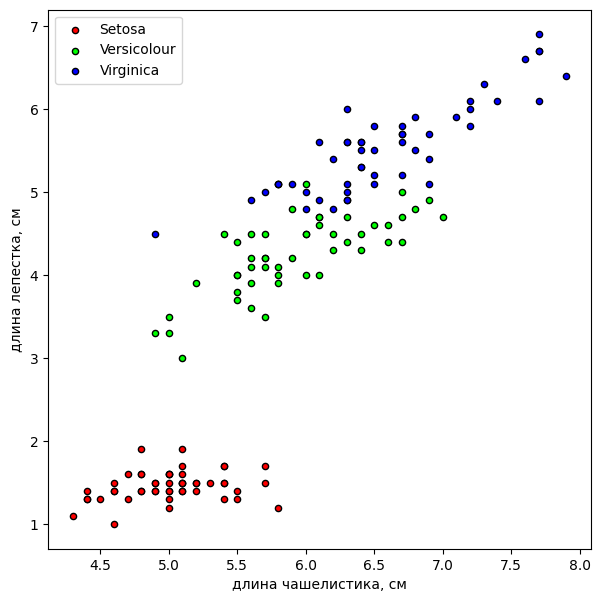

In [ ]:
from matplotlib.colors import ListedColormap
cmap_bold = ListedColormap(['#FF0000',  '#00FF00', '#0000FF'])

K = 3
x = X[-1]

fig, ax = plt.subplots(figsize=(7,7))
for i, iris_class in enumerate(['Setosa', 'Versicolour', 'Virginica']):
    idx = y==i
    ax.scatter(X[idx,0], X[idx,2],
               c=cmap_bold.colors[i], edgecolor='k',
               s=20, label=iris_class);

ax.set(xlabel='длина чашелистика, см', ylabel='длина лепестка, см')
ax.legend();

## 3. Обучение модели дерево решений

### 3.1. Дерево решений с критерием "Индекс Джини"

In [ ]:
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=0)

clf_gini.fit(X_train, y_train)

# Прогноз на тестовых данных
y_pred_gini = clf_gini.predict(X_test)

In [ ]:
# Точность модели на тестовых данных
accuracy = accuracy_score(y_test, y_pred_gini)*100
print('Точность модели на тестовой выборке: ' + str(round(accuracy, 2)) + ' %.')

Точность модели на тестовой выборке: 97.78 %.


In [ ]:
# Метрики на обучающей выборке
y_pred_train_gini = clf_gini.predict(X_train)

accuracy = accuracy_score(y_train, y_pred_train_gini)*100
print('Точность модели на обучающей выборке: ' + str(round(accuracy, 2)) + ' %.')

Точность модели на обучающей выборке: 94.29 %.


### Визуализация границ классов

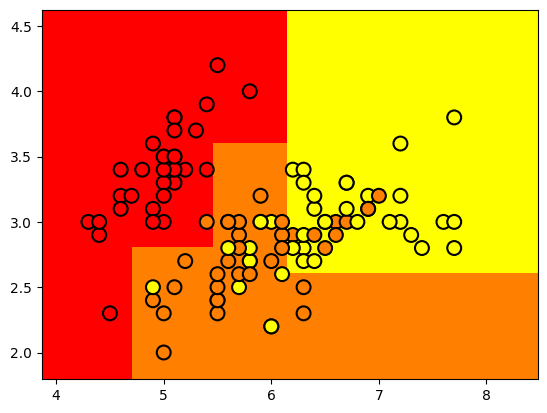

In [ ]:
X_2d = X[:,0:2]

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(X_2d, y, test_size = 0.3, random_state = 42)

clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)

clf_gini.fit(X_2d_train, y_2d_train)

# Прогноз на тестовых данных
y_pred_gini = clf_gini.predict(X_2d_test)

# Визуализация
def get_grid(data):
    x_min, x_max = X_2d_train[:, 0].min()*0.9, X_2d_train[:, 0].max()*1.1
    y_min, y_max = X_2d_train[:, 1].min()*0.9, X_2d_train[:, 1].max()*1.1
    return np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

xx, yy = get_grid(X_2d_test)
y_pred = clf_gini.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.pcolormesh(xx, yy, y_pred, cmap='autumn')
plt.scatter(X_2d_train[:, 0], X_2d_train[:, 1],
            c=y_2d_train, s=100, cmap='autumn',
            edgecolors='black', linewidth=1.5
);

### 3.2. Дерево решений с критерием "Информационная энтропия"

In [ ]:
clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

clf_en.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [ ]:
# Прогноз
y_pred_en = clf_en.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred_en)*100
print('Точность модели на тестовой выборке: ' + str(round(accuracy, 2)) + ' %.')

Точность модели на тестовой выборке: 97.78 %.


In [ ]:
# Метрики на обучающей выборке
y_pred_train_en = clf_en.predict(X_train)

accuracy = accuracy_score(y_train, y_pred_train_en)*100
print('Точность модели на обучающей выборке: ' + str(round(accuracy, 2)) + ' %.')

Точность модели на обучающей выборке: 95.24 %.


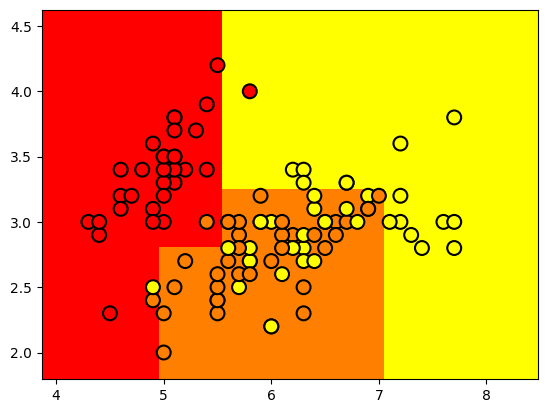

In [ ]:
X_2d = X[:,0:2]

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(X_2d, y, test_size = 0.3, random_state = 42)

clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

clf_en.fit(X_2d_train, y_2d_train)

# Прогноз на тестовых данных
y_pred_gini = clf_en.predict(X_2d_test)

# Визуализация
def get_grid(data):
    x_min, x_max = X_2d_train[:, 0].min()*0.9, X_2d_train[:, 0].max()*1.1
    y_min, y_max = X_2d_train[:, 1].min()*0.9, X_2d_train[:, 1].max()*1.1
    return np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

xx, yy = get_grid(X_2d_test)
y_pred = clf_en.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.pcolormesh(xx, yy, y_pred, cmap='autumn')
plt.scatter(X_2d_train[:, 0], X_2d_train[:, 1],
            c=y_2d_train, s=100, cmap='autumn',
            edgecolors='black', linewidth=1.5
);

## 4. Сравнение моделей

In [ ]:
print(classification_report(y_test, y_pred_en))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [ ]:
print(classification_report(y_test, y_pred_gini))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        19
           1       0.50      0.85      0.63        13
           2       0.33      0.15      0.21        13

    accuracy                           0.67        45
   macro avg       0.61      0.63      0.59        45
weighted avg       0.66      0.67      0.64        45



# 5. Подбор параметров для дерева решений

Датасет

Titanic:

- `Survived` - выжил/не выжил
- `Age` - возраст
- `Fare` - стоимость билета
- `C`,`Q` - порт посадки. Если оба значения =0, то третий порт `S`
- `Family` - наличие семьи на борту
- `Child`, `Female` - пол (М, Ж, ребенок). Если ни `Child` ни `Female`, то `Male`
- `Class_1`, `Class_2` - класс каюты. Если ни `Class_1` ни `Class_2`, тогда `Class_3`

In [ ]:
df = pd.read_csv('sample_data/clear_train.csv')
df.to_pickle('titanic_clean.pickle')

titanic_dataframe = pd.read_pickle('titanic_clean.pickle')

In [ ]:
titanic_dataframe.head()

,PassengerId,Pclass,Sex,Age,Fare,Family,Is_Alone,Have_Age,Have_Cabin,Emb_C,Emb_Q,Emb_S,Title_Aristocratic.,Title_Master.,Title_Miss.,Title_Mr.,Title_Mrs.,Survived
0,1,3,0,22.0,7.2500,1,0,1,0,0,0,1,0,0,0,1,0,0
1,2,1,1,38.0,71.2833,1,0,1,1,1,0,0,0,0,0,0,1,1
2,3,3,1,26.0,7.9250,0,1,1,0,0,0,1,0,0,1,0,0,1
3,4,1,1,35.0,53.1000,1,0,1,1,0,0,1,0,0,0,0,1,1
4,5,3,0,35.0,8.0500,0,1,1,0,0,0,1,0,0,0,1,0,0


In [ ]:
titanic_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PassengerId          891 non-null    int64  
 1   Pclass               891 non-null    int64  
 2   Sex                  891 non-null    int64  
 3   Age                  891 non-null    float64
 4   Fare                 891 non-null    float64
 5   Family               891 non-null    int64  
 6   Is_Alone             891 non-null    int64  
 7   Have_Age             891 non-null    int64  
 8   Have_Cabin           891 non-null    int64  
 9   Emb_C                891 non-null    int64  
 10  Emb_Q                891 non-null    int64  
 11  Emb_S                891 non-null    int64  
 12  Title_Aristocratic.  891 non-null    int64  
 13  Title_Master.        891 non-null    int64  
 14  Title_Miss.          891 non-null    int64  
 15  Title_Mr.            891 non-null    int

In [ ]:
titanic_dataframe.describe()

,PassengerId,Pclass,Sex,Age,Fare,Family,Is_Alone,Have_Age,Have_Cabin,Emb_C,Emb_Q,Emb_S,Title_Aristocratic.,Title_Master.,Title_Miss.,Title_Mr.,Title_Mrs.,Survived
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,0.352413,29.390202,32.674620,0.904602,0.602694,0.801347,0.228956,0.188552,0.086420,0.725028,0.025814,0.044893,0.207632,0.580247,0.141414,0.383838
std,257.353842,0.836071,0.477990,13.265322,49.608084,1.613459,0.489615,0.399210,0.420397,0.391372,0.281141,0.446751,0.158668,0.207186,0.405840,0.493796,0.348644,0.486592
min,1.000000,1.000000,0.000000,0.420000,4.012500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,0.000000,21.000000,7.925000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,446.000000,3.000000,0.000000,30.000000,14.500000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,668.500000,3.000000,1.000000,35.000000,31.275000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,891.000000,3.000000,1.000000,80.000000,512.329200,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# количество пропущенных значений
titanic_dataframe.isna().sum()

,0
PassengerId,0
Pclass,0
Sex,0
Age,0
Fare,0
Family,0
Is_Alone,0
Have_Age,0
Have_Cabin,0
Emb_C,0


In [ ]:
X = titanic_dataframe.drop("Survived", axis=1)
y = titanic_dataframe["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 22)

In [ ]:
parameters = {'criterion': ['gini', 'entropy'],
    'min_samples_split': [3, 5, 8, 10],
    'min_samples_leaf': [1, 3, 5, 7],
    'max_depth': [3, 4, 5, 6, 7, 8]
}

DTree = DecisionTreeClassifier(max_features='sqrt', random_state=22)

model = GridSearchCV(
    DTree,
    parameters,
    cv=5
)

model.fit(X_train, y_train)

print(model.best_params_)
print(round(model.best_score_, 2))

{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 8}
0.83
